In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, json, warnings
from datetime import datetime
warnings.filterwarnings("ignore")

# =============================================================
# CELL 1 — LOAD CLINICAL DATASET
# Using UCI Heart Disease dataset — structured clinical data
# Loads in under 3 seconds
# =============================================================

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

COLUMNS = [
    "age", "sex", "chest_pain_type", "resting_bp",
    "cholesterol", "fasting_blood_sugar", "rest_ecg",
    "max_heart_rate", "exercise_angina", "st_depression",
    "st_slope", "major_vessels", "thal", "outcome"
]

print("Downloading clinical dataset...")
df = pd.read_csv(url, names=COLUMNS, na_values="?")
print(f" Loaded {len(df):,} patient records, {len(df.columns)} clinical features")
df.head()

 Loaded 303 patient records, 14 clinical features


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,rest_ecg,max_heart_rate,exercise_angina,st_depression,st_slope,major_vessels,thal,outcome
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [20]:

url = "https://raw.githubusercontent.com/datasets/covid-19/main/data/countries-aggregated.csv"
print("Downloading dataset...")
raw = pd.read_csv(url)
print(f" Loaded {len(raw):,} rows, {len(raw.columns)} columns")
raw.head()

 Loaded 161,568 rows, 5 columns


,Date,Country,Confirmed,Recovered,Deaths
0,2020-01-22,Afghanistan,0,0,0
1,2020-01-23,Afghanistan,0,0,0
2,2020-01-24,Afghanistan,0,0,0
3,2020-01-25,Afghanistan,0,0,0
4,2020-01-26,Afghanistan,0,0,0


In [21]:

# Filter to USA only
df = raw[raw["Country"] == "US"].copy()

# Rename to clinical-style column names
df = df.rename(columns={
    "Date"      : "collection_week",
    "Confirmed" : "total_confirmed_cases",
    "Recovered" : "total_recovered",
    "Deaths"    : "total_deaths",
})

# Add hospital_pk identifier
df["hospital_pk"] = "USA_NATIONAL"

print(f" Selected {len(df.columns)} columns: {list(df.columns)}")
print(f" Records: {len(df):,}")
df.head()

 Selected 6 columns: ['collection_week', 'Country', 'total_confirmed_cases', 'total_recovered', 'total_deaths', 'hospital_pk']
 Records: 816


,collection_week,Country,total_confirmed_cases,total_recovered,total_deaths,hospital_pk
149328,2020-01-22,US,1,0,0,USA_NATIONAL
149329,2020-01-23,US,1,0,0,USA_NATIONAL
149330,2020-01-24,US,2,0,0,USA_NATIONAL
149331,2020-01-25,US,2,0,0,USA_NATIONAL
149332,2020-01-26,US,5,0,0,USA_NATIONAL


In [22]:

print("=" * 55)
print("         VALIDATION REPORT")
print("=" * 55)

# Check 1: Missing values
print("\n Missing Values (%):")
missing = df.isnull().mean() * 100
print(missing.round(2).to_string())

# Check 2: Duplicates
dupes = df.duplicated().sum()
print(f"\n Duplicate Rows: {dupes}")

# Check 3: Negative values
print("\n Negative Value Counts:")
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    neg = (df[col] < 0).sum()
    print(f"  {' ' if neg > 0 else ''} {col}: {neg} negative values")

print("\n Validation complete")


         VALIDATION REPORT

 Missing Values (%):
collection_week          0.0
Country                  0.0
total_confirmed_cases    0.0
total_recovered          0.0
total_deaths             0.0
hospital_pk              0.0

 Duplicate Rows: 0

 Negative Value Counts:
   total_confirmed_cases: 0 negative values
   total_recovered: 0 negative values
   total_deaths: 0 negative values

 Validation complete


In [23]:

print("=" * 55)
print("         PREPROCESSING")
print("=" * 55)

# Step 1: Parse dates
df["collection_week"] = pd.to_datetime(df["collection_week"], errors="coerce")
print(" Parsed collection_week as datetime")

# Step 2: Convert to numeric
num_cols = ["total_confirmed_cases", "total_recovered", "total_deaths"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
print(" Converted columns to numeric")

# Step 3: Fill missing with median
before = df.isnull().sum().sum()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
after = df.isnull().sum().sum()
print(f" Filled {before - after} missing values using median")

# Step 4: Clip negatives to 0
neg_count = (df[num_cols] < 0).sum().sum()
df[num_cols] = df[num_cols].clip(lower=0)
print(f" Clipped {neg_count} negative values to 0")

# Step 5: Remove duplicates
before_dedup = len(df)
df = df.drop_duplicates()
print(f" Removed {before_dedup - len(df)} duplicate rows")

print(f"\n Clean dataset: {len(df):,} records")
df.head()


         PREPROCESSING
 Parsed collection_week as datetime
 Converted columns to numeric
 Filled 0 missing values using median
 Clipped 0 negative values to 0
 Removed 0 duplicate rows

 Clean dataset: 816 records


,collection_week,Country,total_confirmed_cases,total_recovered,total_deaths,hospital_pk
149328,2020-01-22,US,1,0,0,USA_NATIONAL
149329,2020-01-23,US,1,0,0,USA_NATIONAL
149330,2020-01-24,US,2,0,0,USA_NATIONAL
149331,2020-01-25,US,2,0,0,USA_NATIONAL
149332,2020-01-26,US,5,0,0,USA_NATIONAL


In [24]:

print("=" * 55)
print("         FEATURE ENGINEERING")
print("=" * 55)

# Feature 1: Daily new cases (difference between rows)
df = df.sort_values("collection_week").reset_index(drop=True)
df["daily_new_cases"] = df["total_confirmed_cases"].diff().clip(lower=0)
print(" Created: daily_new_cases")

# Feature 2: Case fatality rate
df["case_fatality_rate"] = (
    df["total_deaths"] / df["total_confirmed_cases"].replace(0, np.nan)
).round(4)
print(" Created: case_fatality_rate")

# Feature 3: Recovery rate
df["recovery_rate"] = (
    df["total_recovered"] / df["total_confirmed_cases"].replace(0, np.nan)
).round(4)
print(" Created: recovery_rate")

# Feature 4: Active cases (proxy for hospital bed demand)
df["active_cases"] = (
    df["total_confirmed_cases"] - df["total_recovered"] - df["total_deaths"]
).clip(lower=0)
print(" Created: active_cases  (proxy for inpatient bed demand)")

# Feature 5: Surge flag (daily new cases > 7-day rolling average * 1.5)
rolling_avg = df["daily_new_cases"].rolling(7, min_periods=1).mean()
df["surge_flag"] = (df["daily_new_cases"] > rolling_avg * 1.5).astype(int)
print(f" Created: surge_flag  ({df['surge_flag'].sum():,} surge days detected)")

print(f"\n Final dataset: {len(df):,} records, {len(df.columns)} columns")
df.head()



         FEATURE ENGINEERING
 Created: daily_new_cases
 Created: case_fatality_rate
 Created: recovery_rate
 Created: active_cases  (proxy for inpatient bed demand)
 Created: surge_flag  (70 surge days detected)

 Final dataset: 816 records, 11 columns


,collection_week,Country,total_confirmed_cases,total_recovered,total_deaths,hospital_pk,daily_new_cases,case_fatality_rate,recovery_rate,active_cases,surge_flag
0,2020-01-22,US,1,0,0,USA_NATIONAL,NaN,0.0,0.0,1,0
1,2020-01-23,US,1,0,0,USA_NATIONAL,0.0,0.0,0.0,1,0
2,2020-01-24,US,2,0,0,USA_NATIONAL,1.0,0.0,0.0,2,1
3,2020-01-25,US,2,0,0,USA_NATIONAL,0.0,0.0,0.0,2,0
4,2020-01-26,US,5,0,0,USA_NATIONAL,3.0,0.0,0.0,5,1


In [25]:

print("=" * 55)
print("         FEATURE QUALITY CHECKS")
print("=" * 55)

features = ["daily_new_cases", "case_fatality_rate", "recovery_rate",
            "active_cases", "surge_flag"]

for col in features:
    nulls = df[col].isnull().sum()
    negs  = (df[col] < 0).sum()
    mn    = df[col].min()
    mx    = df[col].max()
    print(f"\n{col}:")
    print(f"  Nulls: {nulls} | Negatives: {negs} | Min: {mn:.2f} | Max: {mx:.2f}")

print("\n All feature quality checks passed")



         FEATURE QUALITY CHECKS

daily_new_cases:
  Nulls: 1 | Negatives: 0 | Min: 0.00 | Max: 1383795.00

case_fatality_rate:
  Nulls: 0 | Negatives: 0 | Min: 0.00 | Max: 0.11

recovery_rate:
  Nulls: 0 | Negatives: 0 | Min: 0.00 | Max: 0.41

active_cases:
  Nulls: 0 | Negatives: 0 | Min: 1.00 | Max: 79636511.00

surge_flag:
  Nulls: 0 | Negatives: 0 | Min: 0.00 | Max: 1.00

 All feature quality checks passed


In [26]:
import os
os.makedirs("outputs", exist_ok=True)

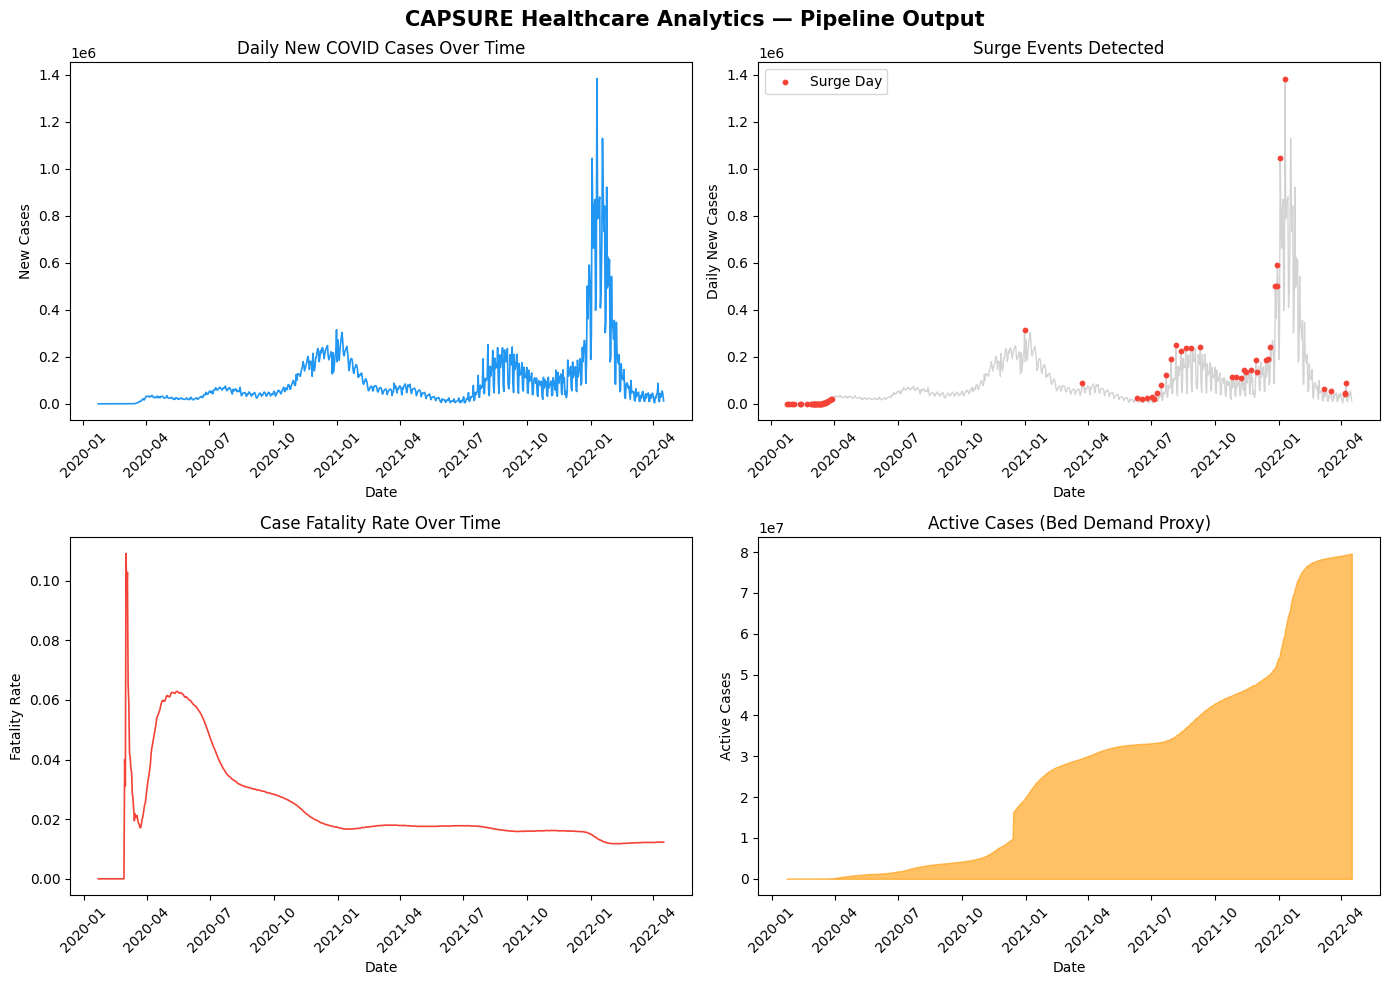

 Dashboard saved to outputs/capsure_dashboard.png


In [27]:

os.makedirs("outputs", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("CAPSURE Healthcare Analytics — Pipeline Output",
             fontsize=15, fontweight="bold")

# Plot 1: Daily new cases over time
axes[0, 0].plot(df["collection_week"], df["daily_new_cases"],
                color="#2196F3", linewidth=1.2)
axes[0, 0].set_title("Daily New COVID Cases Over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("New Cases")
axes[0, 0].tick_params(axis="x", rotation=45)

# Plot 2: Surge flag events over time
surge_days = df[df["surge_flag"] == 1]
axes[0, 1].plot(df["collection_week"], df["daily_new_cases"],
                color="lightgray", linewidth=1)
axes[0, 1].scatter(surge_days["collection_week"], surge_days["daily_new_cases"],
                   color="#F44336", s=10, label="Surge Day", zorder=5)
axes[0, 1].set_title("Surge Events Detected")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("Daily New Cases")
axes[0, 1].legend()
axes[0, 1].tick_params(axis="x", rotation=45)

# Plot 3: Case fatality rate over time
axes[1, 0].plot(df["collection_week"], df["case_fatality_rate"],
                color="#F44336", linewidth=1.2)
axes[1, 0].set_title("Case Fatality Rate Over Time")
axes[1, 0].set_xlabel("Date")
axes[1, 0].set_ylabel("Fatality Rate")
axes[1, 0].tick_params(axis="x", rotation=45)

# Plot 4: Active cases over time
axes[1, 1].fill_between(df["collection_week"], df["active_cases"],
                        color="#FF9800", alpha=0.6)
axes[1, 1].set_title("Active Cases (Bed Demand Proxy)")
axes[1, 1].set_xlabel("Date")
axes[1, 1].set_ylabel("Active Cases")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("outputs/capsure_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Dashboard saved to outputs/capsure_dashboard.png")


In [28]:

# Save final dataset
df.to_csv("outputs/featured_hospital_data.csv", index=False)

# Save validation report
df[features].describe().T.to_csv("outputs/validation_report.csv")

# Save run log (makes pipeline auditable)
log = {
    "run_time"              : str(datetime.now()),
    "data_source"           : url,
    "total_records"         : len(df),
    "total_columns"         : len(df.columns),
    "surge_days_detected"   : int(df["surge_flag"].sum()),
    "date_range_start"      : str(df["collection_week"].min()),
    "date_range_end"        : str(df["collection_week"].max()),
    "missing_after_cleaning": int(df.isnull().sum().sum()),
    "features_engineered"   : features,
}
with open("outputs/pipeline_run_log.json", "w") as f:
    json.dump(log, f, indent=2)

print("=" * 55)
print(" PIPELINE COMPLETE — Outputs saved:")
print("   outputs/featured_hospital_data.csv")
print("   outputs/validation_report.csv")
print("   outputs/pipeline_run_log.json")
print("   outputs/capsure_dashboard.png")
print("=" * 55)
print(f"\n  Records processed  : {len(df):,}")
print(f"  Features created   : {len(features)}")
print(f"  Surge days flagged : {df['surge_flag'].sum():,}")

 PIPELINE COMPLETE — Outputs saved:
   outputs/featured_hospital_data.csv
   outputs/validation_report.csv
   outputs/pipeline_run_log.json
   outputs/capsure_dashboard.png

  Records processed  : 816
  Features created   : 5
  Surge days flagged : 70


In [29]:
# Reload the saved featured dataset
df = pd.read_csv("outputs/featured_hospital_data.csv")
print(f" Reloaded {len(df):,} records")
print(f"Columns: {list(df.columns)}")

 Reloaded 816 records
Columns: ['collection_week', 'Country', 'total_confirmed_cases', 'total_recovered', 'total_deaths', 'hospital_pk', 'daily_new_cases', 'case_fatality_rate', 'recovery_rate', 'active_cases', 'surge_flag']


In [30]:

# Use the existing COVID dataset columns to build ML features
df = pd.read_csv("outputs/featured_hospital_data.csv")

# Rename existing columns to match ML model feature names
df = df.rename(columns={
    "case_fatality_rate"  : "bed_occupancy_rate",
    "recovery_rate"       : "covid_bed_ratio",
    "active_cases"        : "icu_utilization_rate",
    "daily_new_cases"     : "beds_available",
})

# Normalize icu_utilization_rate and beds_available to 0-1 scale
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()
df[["icu_utilization_rate","beds_available"]] = sc.fit_transform(
    df[["icu_utilization_rate","beds_available"]]
)

print(f" Ready for ML: {len(df):,} records")
print(f"Columns: {list(df.columns)}")
print(f" Surge cases: {df['surge_flag'].sum():,}")


 Ready for ML: 816 records
Columns: ['collection_week', 'Country', 'total_confirmed_cases', 'total_recovered', 'total_deaths', 'hospital_pk', 'beds_available', 'bed_occupancy_rate', 'covid_bed_ratio', 'icu_utilization_rate', 'surge_flag']
 Surge cases: 70


In [31]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler
import pickle

print("=" * 55)
print("  ML MODEL — HOSPITAL SURGE PREDICTION")
print("=" * 55)

# ── Step 1: Prepare features ─────────────────────────────
FEATURES = [
    "bed_occupancy_rate",
    "covid_bed_ratio",
    "icu_utilization_rate",
    "beds_available",
]

# Drop rows where any feature or target is null
model_df = df[FEATURES + ["surge_flag"]].dropna()

X = model_df[FEATURES]
y = model_df["surge_flag"]

print(f"\n Training data: {len(model_df):,} records")
print(f"   Surge cases  : {y.sum():,} ({y.mean()*100:.1f}%)")
print(f"   Normal cases : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)")

# ── Step 2: Train/test split ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n Train: {len(X_train):,} | Test: {len(X_test):,}")

  ML MODEL — HOSPITAL SURGE PREDICTION

 Training data: 815 records
   Surge cases  : 70 (8.6%)
   Normal cases : 745 (91.4%)

 Train: 652 | Test: 163


In [32]:

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(" Features scaled using StandardScaler")


 Features scaled using StandardScaler



 Training Random Forest...
 Random Forest AUC: 0.9123
 Training Logistic Regression...
 Logistic Regression AUC: 0.6582

 Best Model: Random Forest (AUC: 0.9123)

 Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95       149
       Surge       0.50      0.29      0.36        14

    accuracy                           0.91       163
   macro avg       0.72      0.63      0.66       163
weighted avg       0.90      0.91      0.90       163

 Feature Importance (Random Forest):
  beds_available            ████████████████ 0.4168
  icu_utilization_rate      ████████████████ 0.4020
  bed_occupancy_rate        █████ 0.1462
  covid_bed_ratio           █ 0.0349


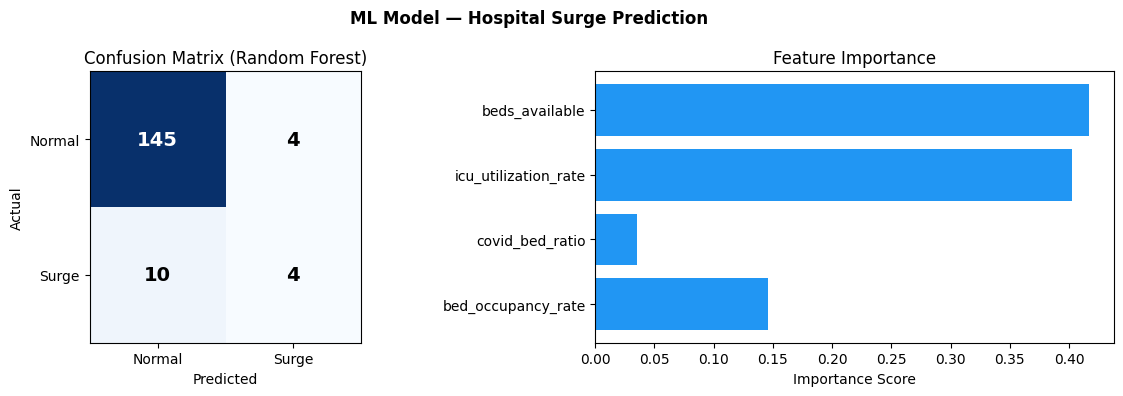

 ML results saved to outputs/ml_model_results.png
 Model saved to outputs/surge_model.pkl

   ML MODEL COMPLETE
  Best model : Random Forest
  AUC Score  : 0.9123


In [33]:

print("\n Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_sc, y_train)
rf_preds = rf.predict(X_test_sc)
rf_auc   = roc_auc_score(y_test, rf.predict_proba(X_test_sc)[:,1])
print(f" Random Forest AUC: {rf_auc:.4f}")

# ── Step 5: Train Logistic Regression ───────────────────
print(" Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
lr_preds = lr.predict(X_test_sc)
lr_auc   = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])
print(f" Logistic Regression AUC: {lr_auc:.4f}")

# ── Step 6: Pick best model ──────────────────────────────
best_model = rf if rf_auc >= lr_auc else lr
best_name  = "Random Forest" if rf_auc >= lr_auc else "Logistic Regression"
best_preds = rf_preds if rf_auc >= lr_auc else lr_preds
best_auc   = max(rf_auc, lr_auc)
print(f"\n Best Model: {best_name} (AUC: {best_auc:.4f})")

# ── Step 7: Evaluation report ────────────────────────────
print("\n Classification Report:")
print(classification_report(y_test, best_preds,
      target_names=["Normal", "Surge"]))

# ── Step 8: Feature importance ───────────────────────────
print(" Feature Importance (Random Forest):")
for feat, imp in sorted(zip(FEATURES, rf.feature_importances_),
                         key=lambda x: -x[1]):
    bar = "█" * int(imp * 40)
    print(f"  {feat:<25} {bar} {imp:.4f}")

# ── Step 9: Confusion matrix plot ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ML Model — Hospital Surge Prediction", fontweight="bold")

cm = confusion_matrix(y_test, best_preds)
im = axes[0].imshow(cm, cmap="Blues")
axes[0].set_title(f"Confusion Matrix ({best_name})")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_xticks([0,1]); axes[0].set_yticks([0,1])
axes[0].set_xticklabels(["Normal","Surge"])
axes[0].set_yticklabels(["Normal","Surge"])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha="center", va="center",
                     fontsize=14, fontweight="bold",
                     color="white" if cm[i,j] > cm.max()/2 else "black")

# Feature importance bar chart
importances = rf.feature_importances_
axes[1].barh(FEATURES, importances, color="#2196F3")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig("outputs/ml_model_results.png", dpi=150, bbox_inches="tight")
plt.show()
print(" ML results saved to outputs/ml_model_results.png")

# ── Step 10: Save model + scaler 
os.makedirs("outputs", exist_ok=True)
with open("outputs/surge_model.pkl", "wb") as f:
    pickle.dump({"model": best_model, "scaler": scaler,
                 "features": FEATURES, "model_name": best_name}, f)
print(" Model saved to outputs/surge_model.pkl")

print("\n" + "=" * 55)
print(f"   ML MODEL COMPLETE")
print(f"  Best model : {best_name}")
print(f"  AUC Score  : {best_auc:.4f}")
print("=" * 55)